In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from IPython.core.pylabtools import figsize
from matplotlib.ticker import PercentFormatter

In [2]:
match_data = pd.read_csv("results.csv", parse_dates=["date"])



In [157]:
goalscorers = pd.read_csv("goalscorers.csv", parse_dates=["date"])

In [2]:
team_stats_new = pd.read_csv('overall_stats/overall_teams_statistics.csv')

In [6]:
match_data["city"].value_counts().head(20)

city
Kuala Lumpur    737
Bangkok         579
Doha            552
London          441
Budapest        433
Kuwait City     375
Montevideo      372
Vienna          361
Oslo            356
Copenhagen      354
Glasgow         353
Buenos Aires    331
Dublin          322
Santiago        321
Belfast         319
Nairobi         316
Jakarta         311
Lima            307
Seoul           307
Cairo           298
Name: count, dtype: int64

In [73]:
match_data['match_id'] = (
    match_data['date'].astype(str) + '_' +
    match_data['home_team'] + '_' +
    match_data['away_team']
)

goalscorers['match_id'] = (
    goalscorers['date'].astype(str) + '_' +
    goalscorers['home_team'] + '_' +
    goalscorers['away_team']
)

goalscorers_count = goalscorers.groupby(['match_id', 'team']).size().reset_index(name='recorded_goals')

match_home = match_data[['match_id', 'date', 'home_team', 'away_team',
                         'home_score', 'away_score']].copy()
match_home['team'] = match_home['home_team']
match_home['official_goals'] = match_home['home_score']

match_away = match_data[['match_id', 'date', 'home_team', 'away_team',
                         'home_score', 'away_score']].copy()
match_away['team'] = match_away['away_team']
match_away['official_goals'] = match_away['away_score']

match_combine = pd.concat([
    match_home[['match_id', 'date', 'team', 'official_goals', 'home_team', 'away_team', 'home_score', 'away_score']],
    match_away[['match_id', 'date', 'team', 'official_goals', 'home_team', 'away_team', 'home_score', 'away_score']]
])

comparison = match_combine.merge(
    goalscorers_count,
    on=['match_id', 'team'],
    how='left'
)

comparison['recorded_goals'] = comparison['recorded_goals'].fillna(0).astype(int)

comparison['missing_goals'] = comparison['official_goals'] - comparison['recorded_goals']

comparison.head



<bound method NDFrame.head of                                      match_id       date      team  \
0                 1872-11-30_Scotland_England 1872-11-30  Scotland   
1                 1873-03-08_England_Scotland 1873-03-08   England   
2                 1874-03-07_Scotland_England 1874-03-07  Scotland   
3                 1875-03-06_England_Scotland 1875-03-06   England   
4                 1876-03-04_Scotland_England 1876-03-04  Scotland   
...                                       ...        ...       ...   
97341  2025-10-14_Republic of Ireland_Armenia 2025-10-14   Armenia   
97342              2025-10-14_Estonia_Moldova 2025-10-14   Moldova   
97343                 2025-10-14_Italy_Israel 2025-10-14    Israel   
97344               2025-10-14_Andorra_Serbia 2025-10-14    Serbia   
97345               2025-10-14_Latvia_England 2025-10-14   England   

       official_goals            home_team away_team  home_score  away_score  \
0                   0             Scotland   Engl

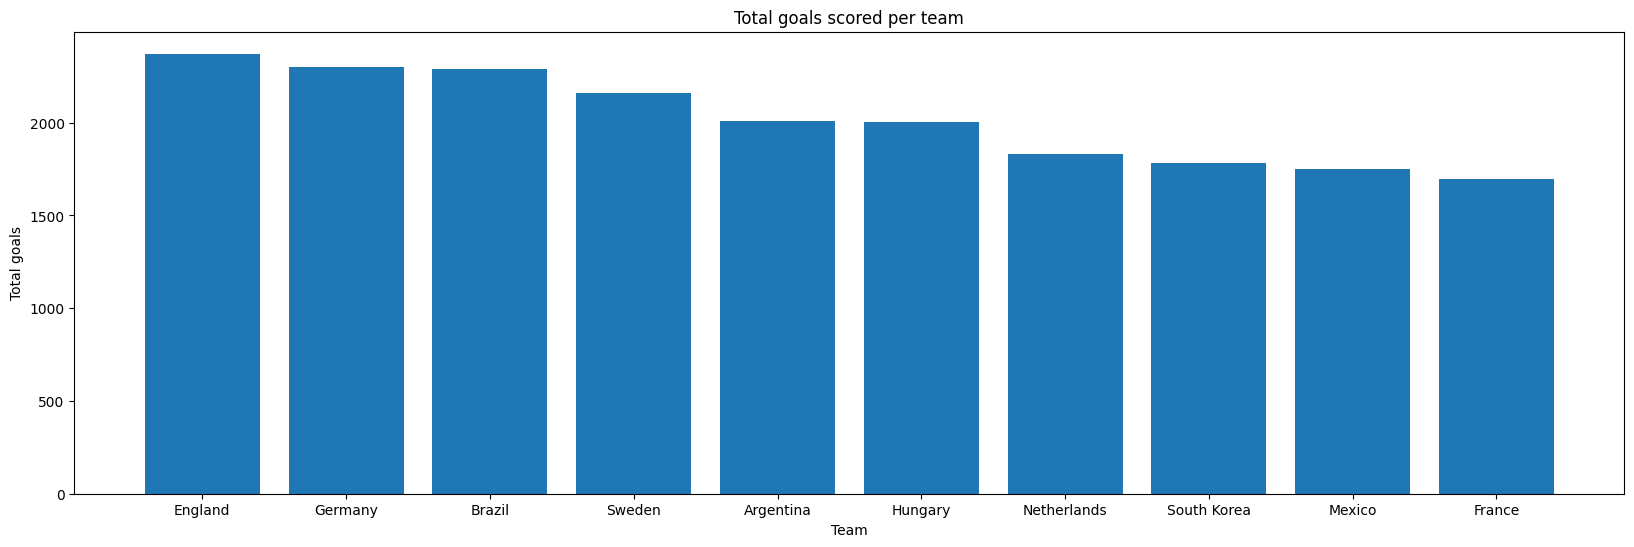

In [54]:
total_goals_per_team = team_stats_new.groupby(
    team_stats_new['team'])['total_goals'].sum()
total_goals_per_team = total_goals_per_team.sort_values(ascending=False).head(10)
fig, ax = plt.subplots(figsize=(20, 6))
ax.bar(total_goals_per_team.index, total_goals_per_team)
ax.set_title('Total goals scored per team')
ax.set_xlabel('Team')
ax.set_ylabel('Total goals')
plt.show()


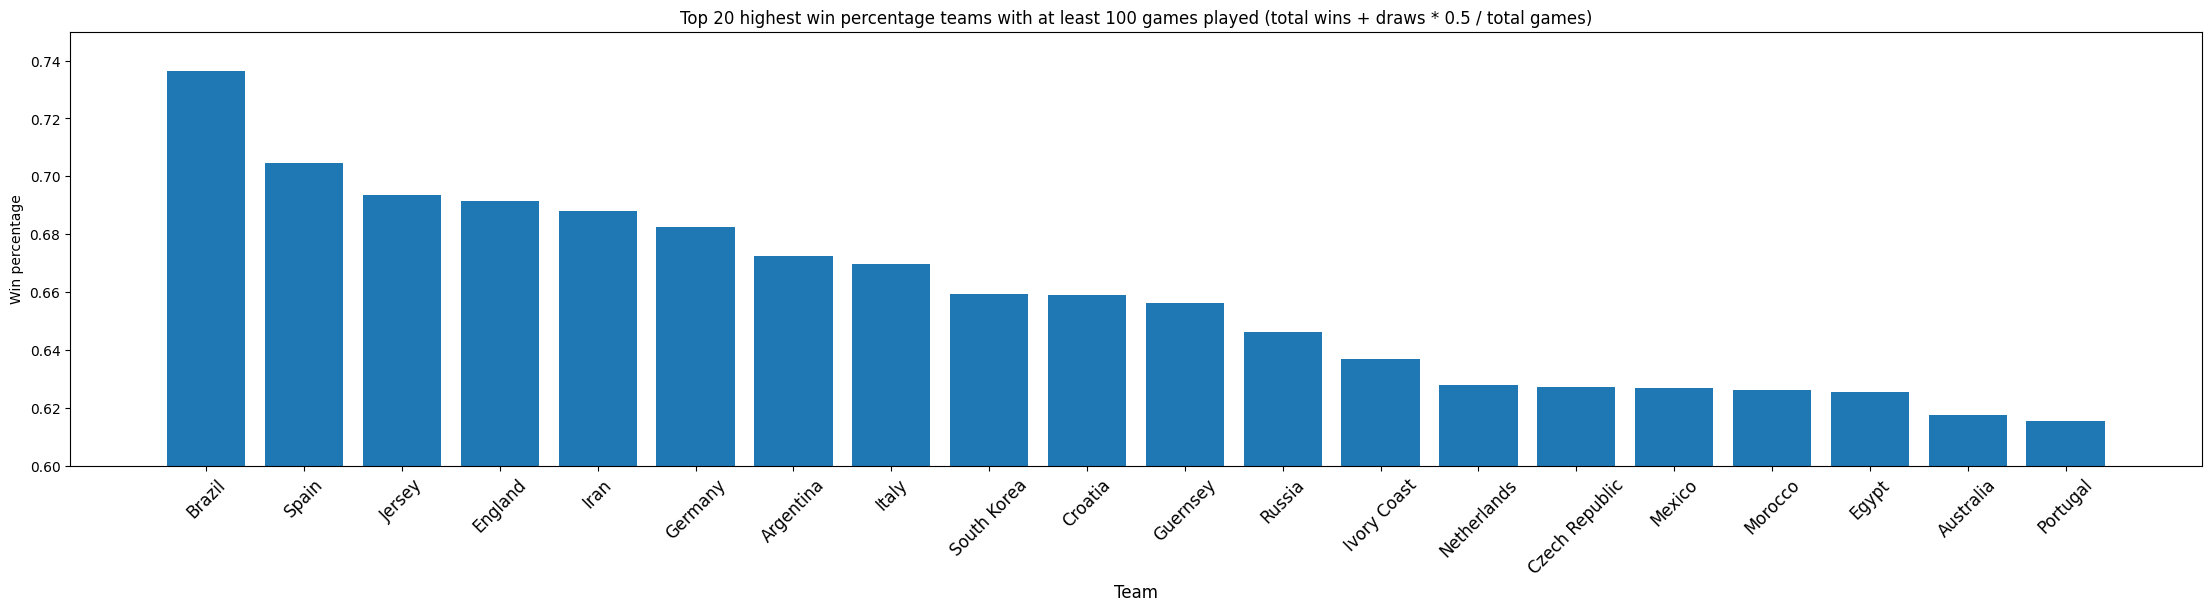

In [19]:
top_win_percentage = team_stats_new.query('games_played > 100')
top_win_percentage = top_win_percentage.groupby(
    top_win_percentage['team'])['win_percentage'].sum()
top_win_percentage = top_win_percentage.sort_values(ascending=False).head(20)
fig, ax = plt.subplots(figsize=(22, 6), layout='constrained')
ax.bar(top_win_percentage.index, top_win_percentage)
ax.yaxis.set_major_formatter(plt.FormatStrFormatter('%.2f'))
ax.set_ylim(0.6, 0.75)
ax.set_title('Top 20 highest win percentage teams with at least 100 games played (total wins + draws * 0.5 / total games)')
ax.set_xlabel('Team', fontsize=12)
ax.set_ylabel('Win percentage')
labels = ax.get_xticklabels()
plt.setp(labels, rotation=45, fontsize=12)
plt.show()

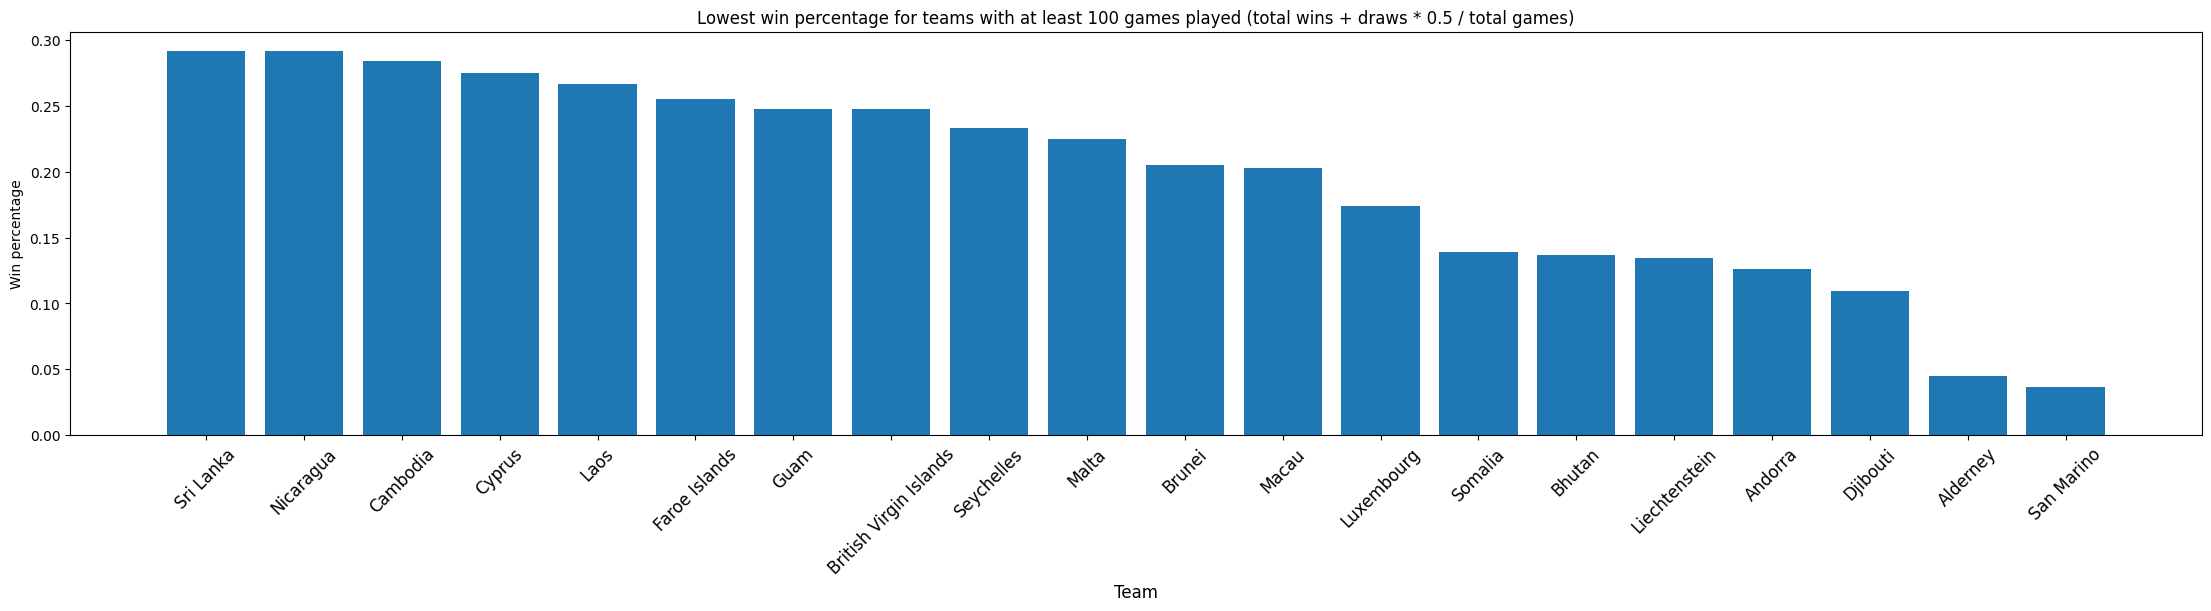

In [10]:
lowest_win_percentage = team_stats_new.query('games_played > 100')
lowest_win_percentage = lowest_win_percentage.groupby(
    lowest_win_percentage['team'])['win_percentage'].sum()
lowest_win_percentage = lowest_win_percentage.sort_values(ascending=False).tail(20)
fig, ax = plt.subplots(figsize=(22, 6), layout='constrained')
ax.bar(lowest_win_percentage.index, lowest_win_percentage)
ax.yaxis.set_major_formatter(plt.FormatStrFormatter('%.2f'))
ax.set_title('Lowest win percentage for teams with at least 100 games played (total wins + draws * 0.5 / total games)')
ax.set_xlabel('Team', fontsize=12)
ax.set_ylabel('Win percentage')
labels = ax.get_xticklabels()
plt.setp(labels, rotation=45, fontsize=12)
plt.show()

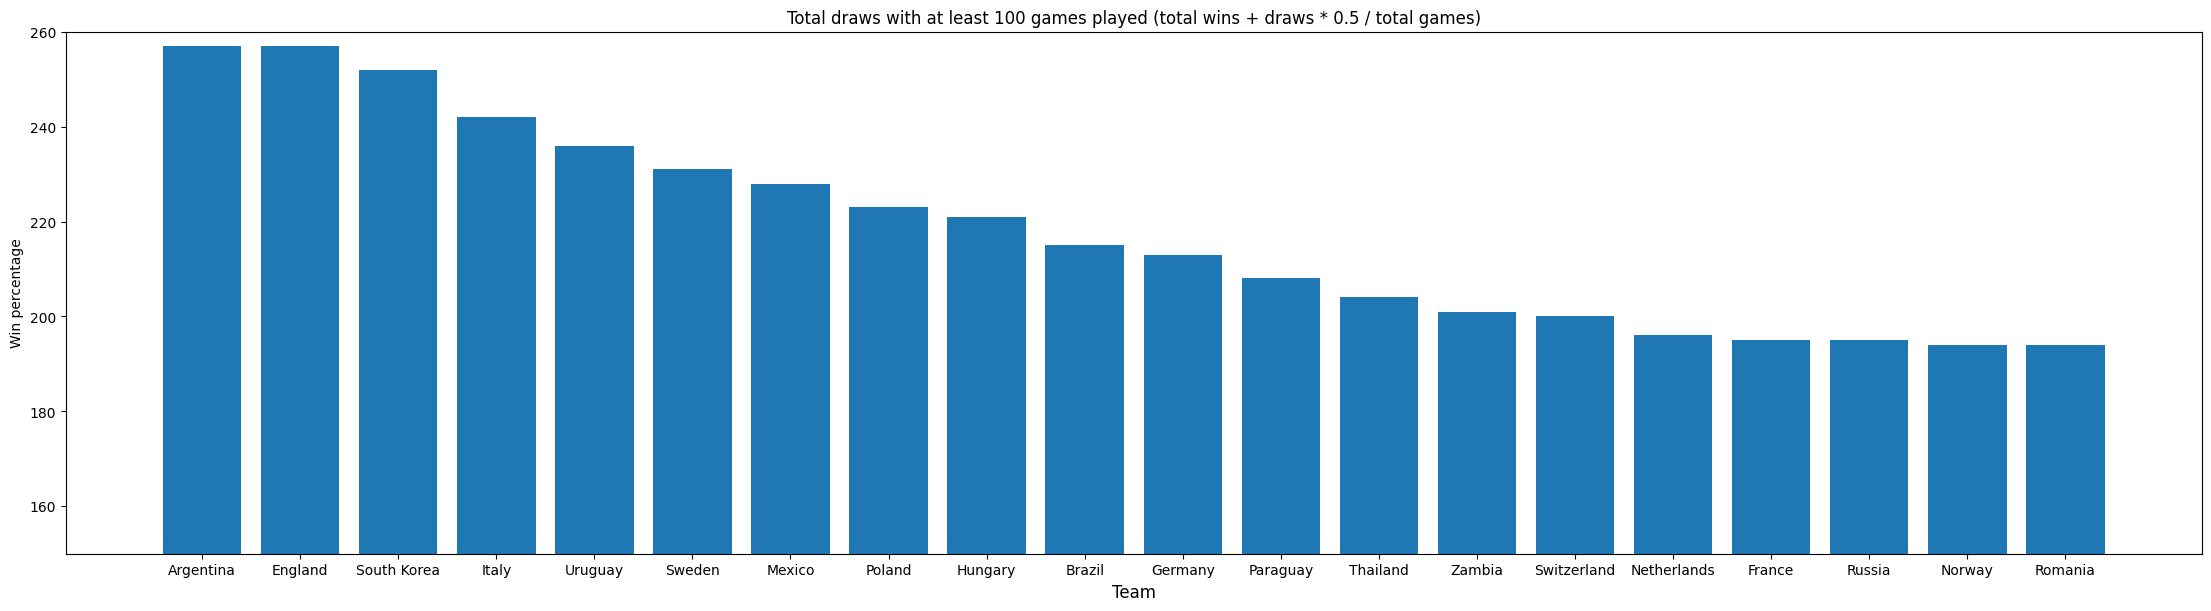

In [20]:
most_draws = team_stats_new.query('games_played > 100')
most_draws = most_draws.groupby(
    most_draws['team'])['total_draws'].sum()
most_draws = most_draws.sort_values(ascending=False).head(20)
fig, ax = plt.subplots(figsize=(22, 6), layout='constrained')
ax.bar(most_draws.index, most_draws)
ax.set_ylim(150, 260)
ax.set_title('Total draws with at least 100 games played (total wins + draws * 0.5 / total games)')
ax.set_xlabel('Team', fontsize=12)
ax.set_ylabel('Win percentage')
plt.show()

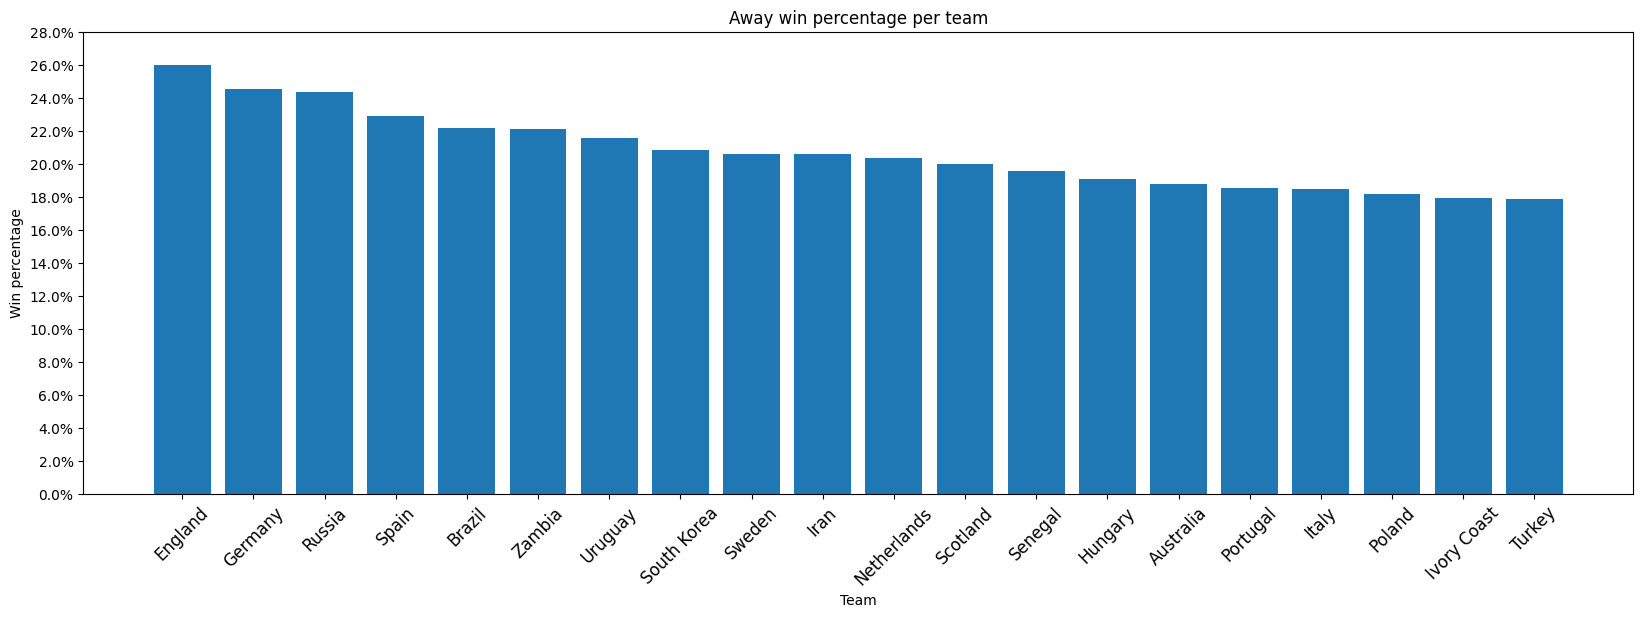

In [36]:
df = pd.read_csv('overall_stats/overall_teams_statistics.csv')
df = df.query('games_played > 500')
away_win_percentage = df.groupby(df['team'])['away_win_percentage'].sum().sort_values(ascending=False)
away_win_percentage = away_win_percentage.head(20)
fig, ax = plt.subplots(figsize=(20, 6))
ax.bar(away_win_percentage.index, away_win_percentage)
ax.set_title('Away win percentage per team')
ax.set_xlabel('Team')
ax.set_ylabel('Win percentage')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.tick_params(axis='x', rotation=45, labelsize=12)
ax.set_yticks(np.arange(0.0, 0.3, 0.02))
plt.show()

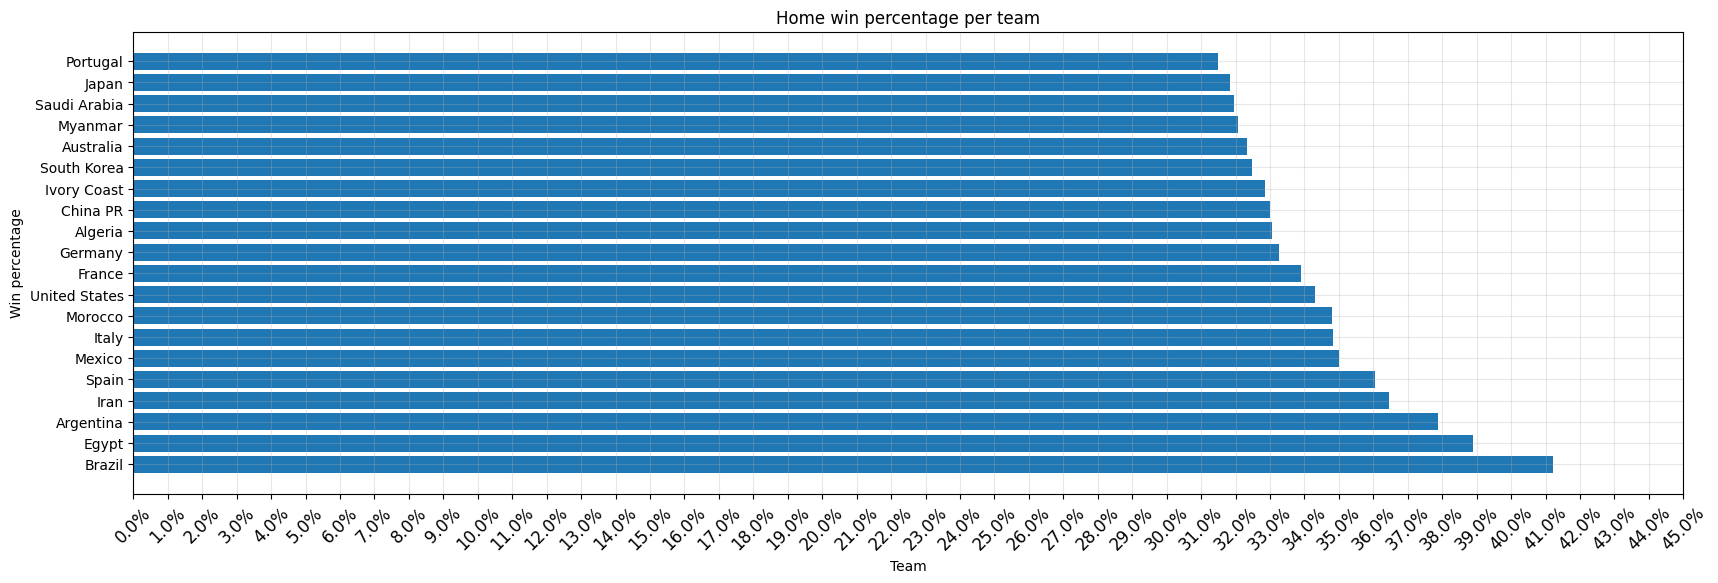

In [47]:
df = pd.read_csv('overall_stats/overall_teams_statistics.csv')
df = df.query('games_played > 500')
home_win_percentage = df.groupby(df['team'])['home_win_percentage'].sum().sort_values(ascending=False)
home_win_percentage = home_win_percentage.head(20)
fig, ax = plt.subplots(figsize=(20, 6))
ax.barh(home_win_percentage.index, home_win_percentage)
ax.set_title('Home win percentage per team')
ax.set_xlabel('Team')
ax.set_ylabel('Win percentage')
ax.set_xticks(np.arange(0.0, 0.46, 0.01))
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.tick_params(axis='x', rotation=45, labelsize=12)
ax.grid(True, alpha=0.3)
plt.show()

Scatter chart for who has the most home and away wins

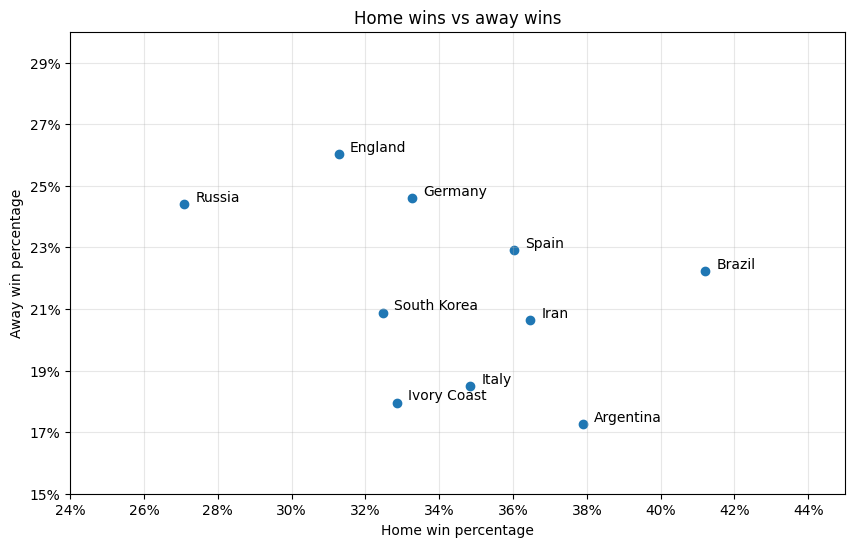

In [37]:
df = pd.read_csv('overall_stats/overall_teams_statistics.csv')

team_stats_sorted = df.sort_values(by='win_percentage')
team_stats_sorted = team_stats_sorted.query('games_played > 500')
team_stats_sorted = team_stats_sorted.tail(10)
home_wins = team_stats_sorted.groupby(
    team_stats_sorted['team'])['home_win_percentage'].sum().tail(10)
away_wins = team_stats_sorted.groupby(
    team_stats_sorted['team'])['away_win_percentage'].sum().tail(10)

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(home_wins, away_wins)
ax.set_title('Home wins vs away wins')
ax.set_xlabel('Home win percentage')
ax.set_ylabel('Away win percentage')
ax.set_xlim(0.24, 0.45)
ax.set_ylim(0.15, 0.3)
ax.set_xticks(np.arange(0.24, 0.45, 0.02))
ax.set_yticks(np.arange(0.15, 0.3, 0.02))
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=False))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=False))
ax.grid(True, alpha=0.3)
for i, txt in enumerate(home_wins.index):
    ax.annotate(txt, (home_wins.iloc[i], away_wins.iloc[i]), ((home_wins.iloc[i]+0.003), (away_wins.iloc[i]+0.001)))
plt.show()

Plot chart for how many home and away goals over time

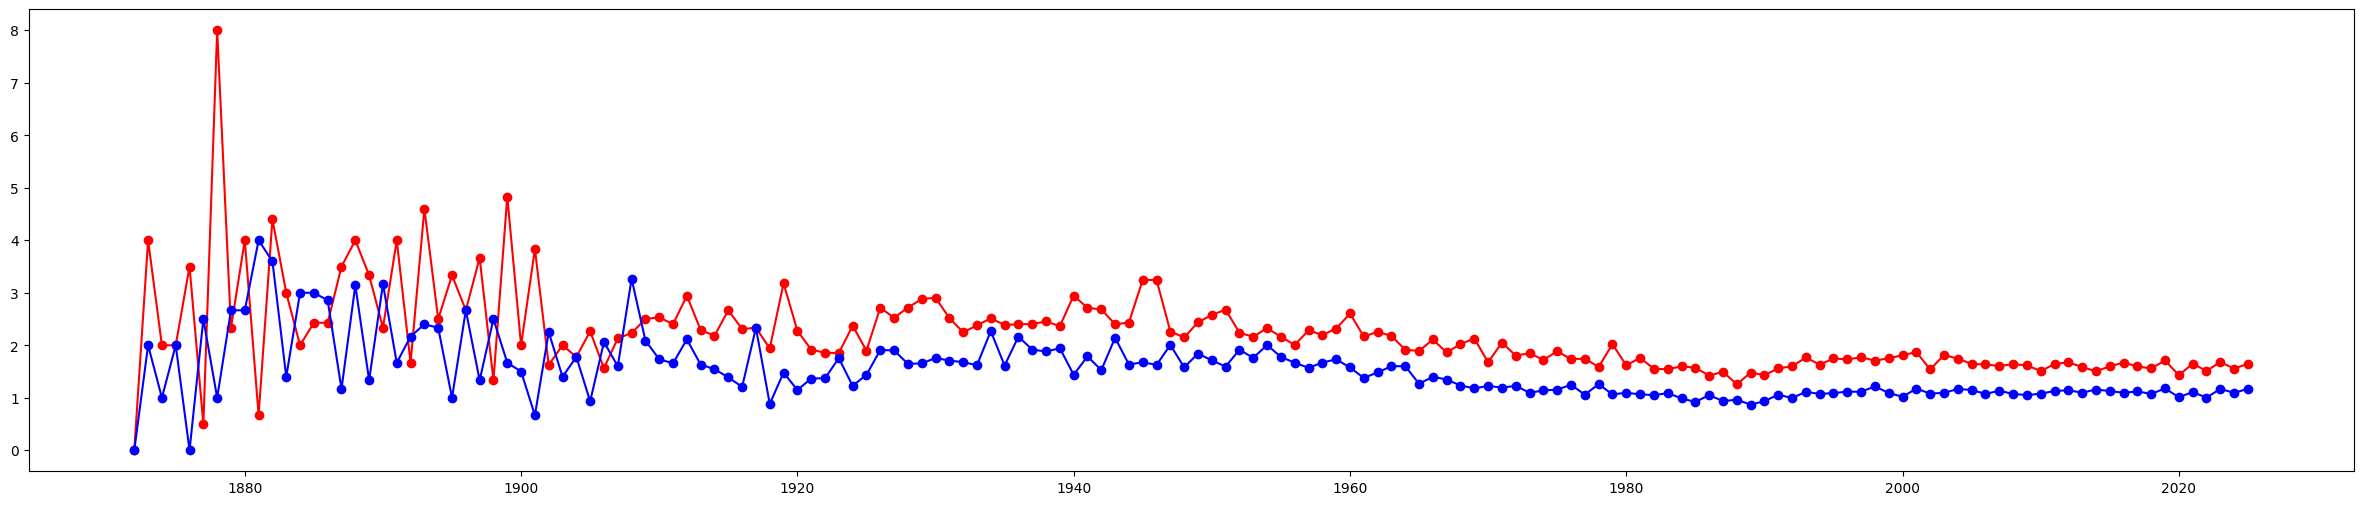

In [80]:
avg_home_goals = match_data.groupby(
    [match_data["date"].dt.year])["home_score"].mean()

avg_away_goals = match_data.groupby(
    [match_data["date"].dt.year])["away_score"].mean()
plt.figure(figsize=(30, 6))
plt.plot(avg_home_goals, label='home', color='red', marker='o')
plt.plot(avg_away_goals, label='away', color='blue', marker='o')

plt.show()

Bar chart for how many goals have been scored at each minute

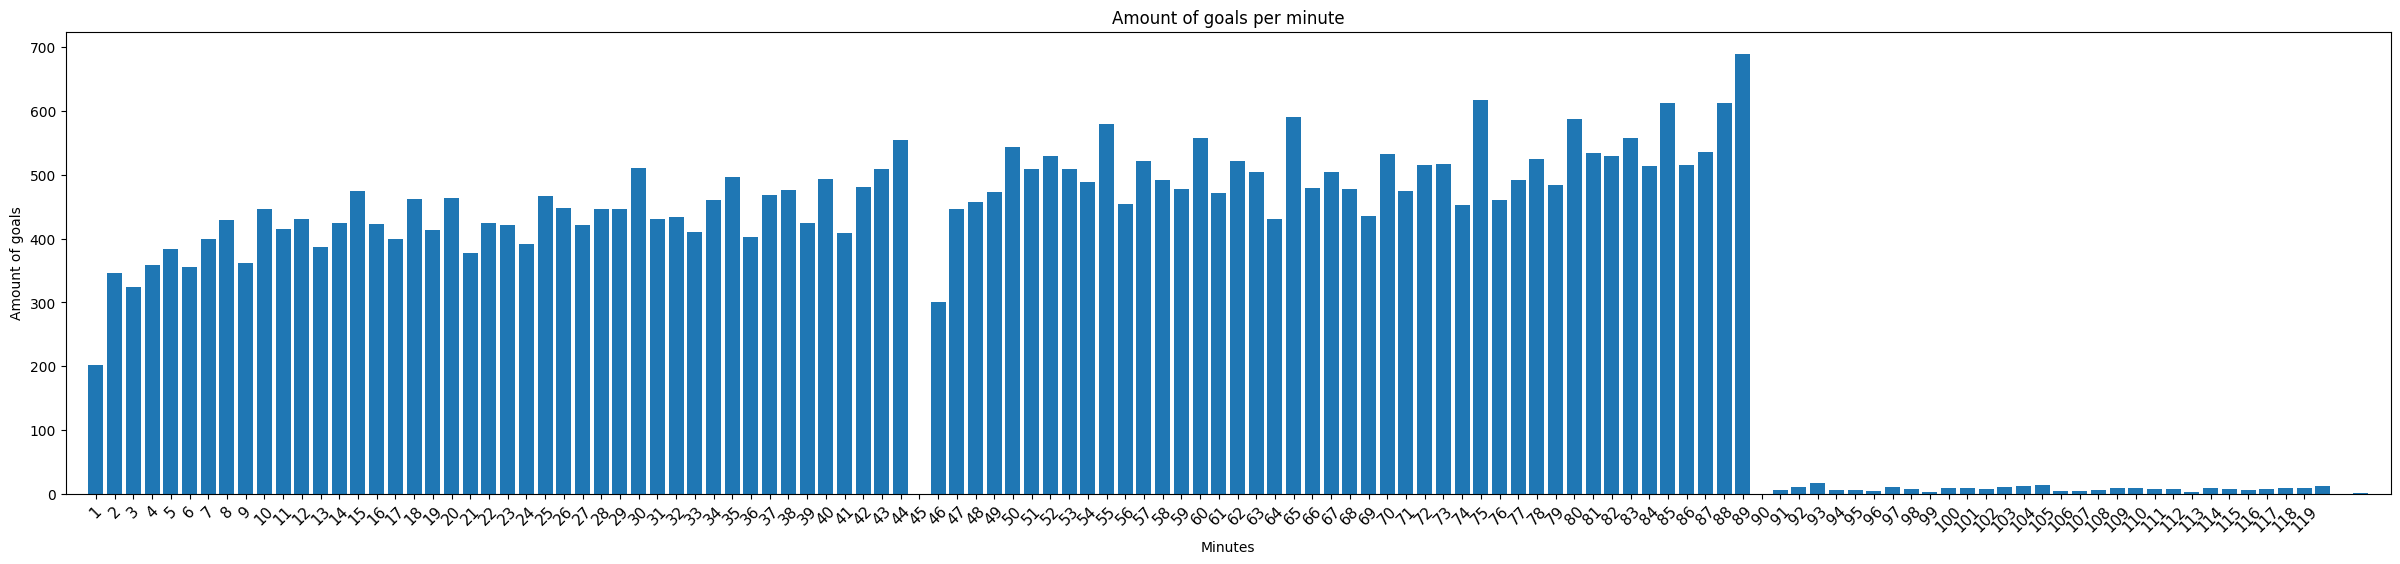

In [158]:
goalscorers_copy = goalscorers.copy()

total_goals = goalscorers_copy['team'].value_counts()
minutes = goalscorers_copy['minute'].value_counts()
#to omit 45 and 90 because it counts all goals 45+ and 90+ as goals in each time frame
minutes = minutes[minutes <900]
fig, ax = plt.subplots(figsize=(30, 6))
ax.bar(minutes.index, minutes)
ax.set_title('Amount of goals per minute')
ax.set_xlabel('Minutes')
ax.set_ylabel('Amount of goals')
ax.set_xticks(np.arange(1, 120, 1))
ax.tick_params(axis='x', rotation=45, labelsize=11)
ax.margins(x=0.01)
plt.show()

Normal goals vs pentalties vs own goals

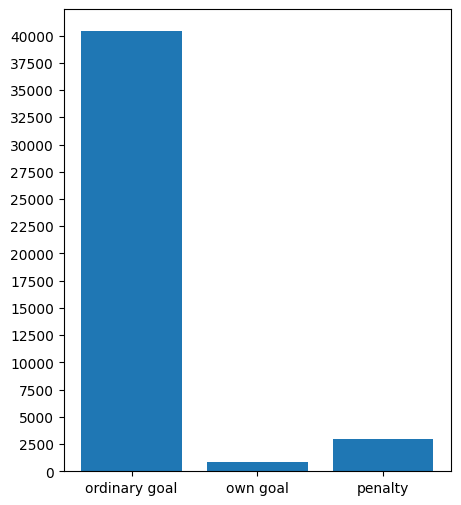

In [186]:
goalscorers_copy = goalscorers.copy()
own_goal = goalscorers_copy[goalscorers_copy['own_goal'] == True].value_counts().sum()
penalty = goalscorers_copy[goalscorers_copy['penalty'] == True].value_counts().sum()
ordinary_goal = goalscorers_copy[(goalscorers_copy['own_goal'] == False) & (goalscorers_copy['penalty'] == False)].value_counts().sum()
goal_types = {'ordinary goal': ordinary_goal, 'own goal': own_goal, 'penalty': penalty}
categories = goal_types.keys()
values = goal_types.values()
fig, ax = plt.subplots(figsize=(5, 6))
ax.bar(categories, values)
ax.set_yticks(np.arange(0, 42000, 2500))
plt.show()



In [205]:
penalty_goals = goalscorers.copy()

teams_penalty_goals = penalty_goals.groupby(['team'])
teams_penalty_goals.head(10)


,date,home_team,away_team,team,scorer,minute,own_goal,penalty
0,1916-07-02,Chile,Uruguay,Uruguay,José Piendibene,44.0,False,False
1,1916-07-02,Chile,Uruguay,Uruguay,Isabelino Gradín,55.0,False,False
2,1916-07-02,Chile,Uruguay,Uruguay,Isabelino Gradín,70.0,False,False
3,1916-07-02,Chile,Uruguay,Uruguay,José Piendibene,75.0,False,False
4,1916-07-06,Argentina,Chile,Argentina,Alberto Ohaco,2.0,False,False
...,...,...,...,...,...,...,...,...
41493,2021-10-07,Nigeria,Central African Republic,Central African Republic,Karl Namnganda,90.0,False,False
42185,2022-01-18,Ghana,Comoros,Comoros,El Fardou Ben Nabouhane,4.0,False,False
42186,2022-01-18,Ghana,Comoros,Comoros,Ahmed Mogni,62.0,False,False
42189,2022-01-18,Ghana,Comoros,Comoros,Ahmed Mogni,85.0,False,False


Making a new dataframe for how many goals each team has scored over time in the worldcup

In [44]:
df = pd.read_csv('world_cup/fifa_world_cups_teams_summary.csv')
all_teams = df['team'].unique()
all_years = df['year'].unique()
all_years_dict = {index: value for index, value in enumerate(all_years)}
new_dict= []
for year in all_years:
    for team in all_teams:
        year_to_get = year
        goals = df[(df['team'] == team) & (df['year'] == year_to_get)]['total_goals_cumulative_sum'].sum()
        while goals < 1 and year_to_get > 1930:
            year_to_get -= 4
            goals = df[(df['team'] == team) & (df['year'] == year_to_get)]['total_goals_cumulative_sum'].sum()
        year_to_get = year
        conceded_goals = df[(df['team'] == team) & (df['year'] == year_to_get)]['total_goals_conceded_cumulative_sum'].sum()
        while conceded_goals < 1 and year_to_get > 1930:
            year_to_get -= 4
            conceded_goals = df[(df['team'] == team) & (df['year'] == year_to_get)]['total_goals_conceded_cumulative_sum'].sum()
        points = df[(df['team'] == team) & (df['year'] == year_to_get)]['total_points_cumulative_sum'].sum()
        while points < 1 and year_to_get > 1930:
            year_to_get -= 4
            points = df[(df['team'] == team) & (df['year'] == year_to_get)]['total_points_cumulative_sum'].sum()
        new_dict.append({'year': year, 'team': team, 'goals': goals, 'conceded_goals': conceded_goals, 'points': points})


df_new = pd.DataFrame(new_dict)
df_new.to_csv('cumulative_stats_over_time_world_cup.csv', index=False)

Getting only world c

World cup goal scorers


In [115]:
df = pd.read_csv('results.csv', parse_dates=["date"])
df = df[df['tournament'] == 'FIFA World Cup']
world_cup_goal_scorers = pd.read_csv('goalscorers.csv', parse_dates=["date"])
all_dates = pd.to_datetime(df['date'].unique()).date
world_cup_goal_scorers = world_cup_goal_scorers[world_cup_goal_scorers['date'].dt.date.isin(all_dates)]

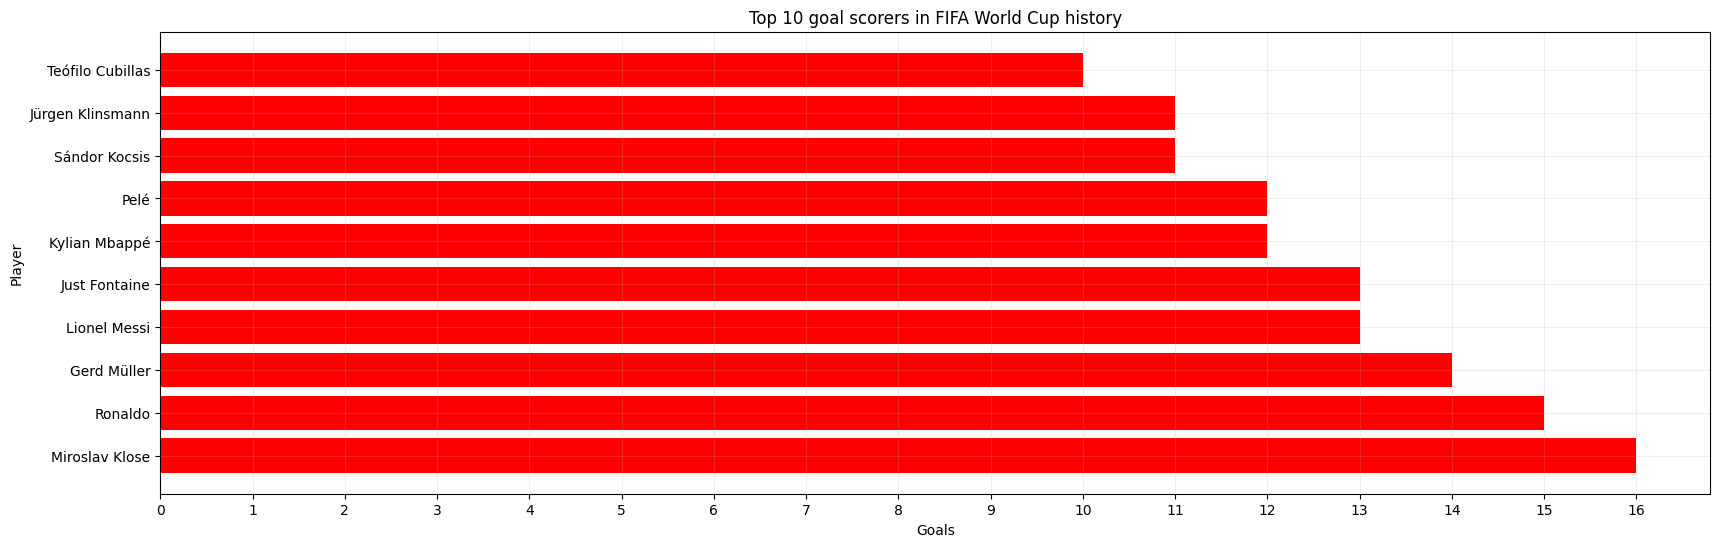

In [133]:
top_goal_scorers_wc = world_cup_goal_scorers.copy()
scorers = top_goal_scorers_wc['scorer'].value_counts()
scorers = scorers.head(10)

fig, ax = plt.subplots(figsize=(20, 6))
ax.barh(scorers.index, scorers, color='red')
ax.set_title('Top 10 goal scorers in FIFA World Cup history')
ax.set_xlabel('Goals')
ax.set_ylabel('Player')
ax.grid(True, alpha=0.2)
ax.set_xticks(np.arange(0, 17, 1))
plt.show()

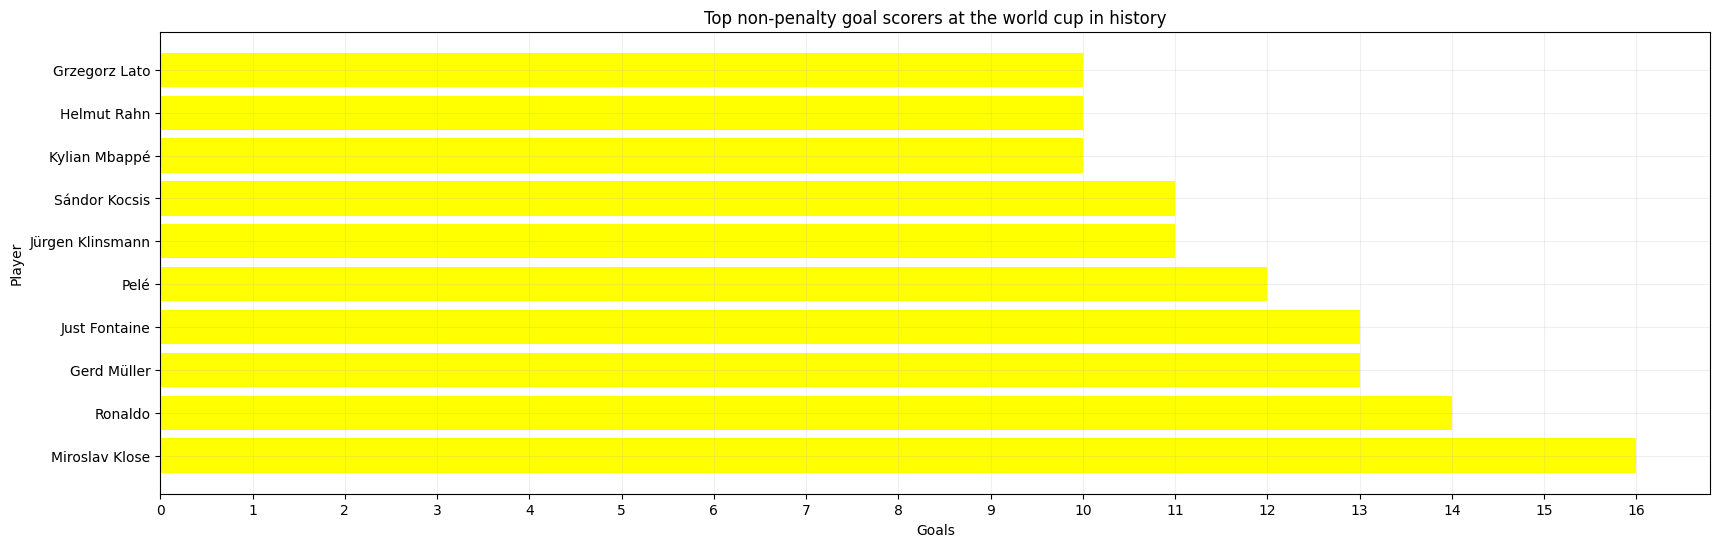

In [150]:
top_goal_scorers_wc_non_penalty = world_cup_goal_scorers.copy()
top_goal_scorers_wc_non_penalty = world_cup_goal_scorers[(world_cup_goal_scorers['penalty'] == False)]
top_goal_scorers_wc_non_penalty = top_goal_scorers_wc_non_penalty['scorer'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(20,6))
ax.barh(top_goal_scorers_wc_non_penalty.index, top_goal_scorers_wc_non_penalty, color="yellow")
ax.set_title("Top non-penalty goal scorers at the world cup in history")
ax.set_xlabel("Goals")
ax.set_ylabel("Player")
ax.set_xticks(np.arange(0, 17, 1))
ax.grid(True, alpha=0.2)
plt.show()

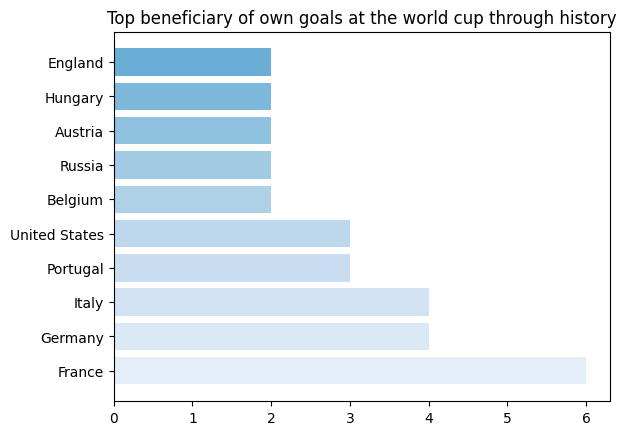

In [177]:
top_own_goal_scorers = world_cup_goal_scorers.copy()
top_own_goal_scorers = top_own_goal_scorers[top_own_goal_scorers['own_goal'] == True]['team'].value_counts().head(10)
colors = plt.get_cmap('Blues')(np.linspace(0.1, 0.5, len(top_own_goal_scorers)))

fig, ax = plt.subplots()
ax.barh(top_own_goal_scorers.index, top_own_goal_scorers, color=colors)
ax.set_title("Top beneficiary of own goals at the world cup through history")
plt.show()
